# 0. Load

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, classification_report, recall_score, precision_score, roc_auc_score, f1_score
from sklearn.metrics import roc_curve, auc
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from xgboost import XGBClassifier
import shap
import optuna

In [2]:
df_org = pd.read_csv("../Data/churn_processed.csv")
df_org.head()

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,52869,0,20.0,Phone,3,7.0,E wallet,Female,4.0,4,Fashion,5,Married,3,0,26.0,5.0,16.0,3.0,229.53
1,52942,0,13.0,Computer,1,9.0,COD,Female,4.0,4,Fashion,3,Single,2,0,26.0,11.0,2.0,9.0,234.38
2,52972,0,16.0,Phone,3,7.0,Debit Card,Male,3.0,4,Laptop & Accessory,3,Divorced,3,0,26.0,5.0,12.0,7.0,174.07
3,53125,0,5.0,Phone,1,16.0,Debit Card,Male,3.0,4,Fashion,4,Married,3,0,26.0,2.0,2.0,9.0,231.48
4,53367,0,9.0,Phone,1,28.0,Debit Card,Female,3.0,4,Laptop & Accessory,2,Divorced,3,1,26.0,1.0,2.0,8.0,165.14


# 1. Preprocessing

In [3]:
# Drop unnecessary column
df_ml = df_org.drop(columns = "CustomerID").copy()

In [4]:
# Encoding
df_ml = pd.get_dummies(df_ml, drop_first = True)

In [5]:
# Check balance
print(df_ml["Churn"].value_counts(normalize = True))

Churn
0    0.831616
1    0.168384
Name: proportion, dtype: float64


# 2. Split

In [6]:
# Split data into Train, Valid, Test 0.7/0.1/0.2
x = df_ml.drop(columns = 'Churn')
y = df_ml['Churn']
train_size, valid_size = [0.7, 0.1]

x_train, x_test, y_train, y_test = train_test_split(x, y, train_size = train_size, random_state = 10)
x_valid, x_test, y_valid, y_test = train_test_split(x_test, y_test, train_size = valid_size/(1 - train_size), random_state = 10)

# 3. Choose model

## a. Initialize

In [7]:
churn_wt = y_train.count()/y_train.sum() - 1

In [8]:
all_mod = {"Random Forest"  : RandomForestClassifier(random_state = 10, class_weight = {0:1, 1:churn_wt}),
           "Hist Gradient Boost" : HistGradientBoostingClassifier(random_state = 10, class_weight = {0:1, 1:churn_wt}),
           "XGBoost" : XGBClassifier(random_state = 10, scale_pos_weight = churn_wt)
            }

## b. Fit models

In [9]:
accuracy = []
precision = []
recall = []
auc_ = []
f1 = []
for mod in all_mod.keys():
    print(f'Running {mod}...')

    model = all_mod[mod]
    model.fit(x_train, y_train)
    y_pred = model.predict(x_valid)

    accuracy.append(accuracy_score(y_valid, y_pred))
    precision.append(precision_score(y_valid, y_pred))
    recall.append(recall_score(y_valid, y_pred))
    f1.append(f1_score(y_valid, y_pred))
    auc_.append(roc_auc_score(y_valid, model.predict_proba(x_valid)[:,1]))

Running Random Forest...
Running Hist Gradient Boost...
Running XGBoost...


## c. Evaluate on valid set

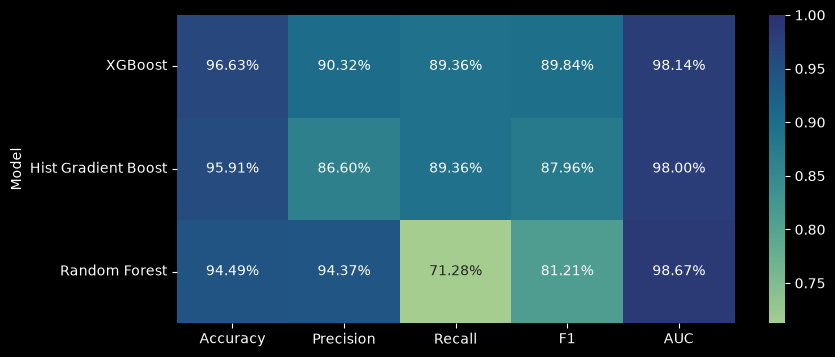

In [10]:
result = pd.DataFrame({
    "Model" : list(all_mod.keys()), 
    "Accuracy" : accuracy, 
    "Precision" : precision, 
    "Recall" : recall,
    "F1": f1,
    "AUC" : auc_
    }).sort_values('F1', ascending = False)

plt.style.use('dark_background')
plt.figure(figsize = (9,4))
sns.heatmap(
    result.set_index("Model"), annot = True,
            fmt = '.2%', cmap = 'crest', vmax = 1
            );

# 4. Optuna

## a. Optimize

In [11]:
def objective(trial):
    params = {
        "n_estimators": trial.suggest_int(
            "n_estimators", 500, 3000
        ),
        "max_depth": trial.suggest_int(
            "max_depth", 5, 25
        ),
        "min_child_weight": trial.suggest_float(
            "min_child_weight", 1e-2, 100.0, log = True
        ),
        "learning_rate": trial.suggest_float(
            "learning_rate", 1e-3, 0.3, log = True
        ),
        "subsample": trial.suggest_float(
            "subsample", 0.6, 1.0
        ),
        "colsample_bytree": trial.suggest_float(
            "colsample_bytree", 0.6, 1.0
        ),
        "gamma": trial.suggest_float(
            "gamma", 1e-8, 10.0, log = True
        ),
        "reg_alpha": trial.suggest_float(
            "reg_alpha", 1e-8, 10.0, log = True
        ),
        "reg_lambda": trial.suggest_float(
            "reg_lambda", 1e-8, 100.0, log = True
        ),
        
        "scale_pos_weight": trial.suggest_float(
            "scale_pos_weight", churn_wt, churn_wt*20, log = True
        ),
        "n_jobs": 1,
        "random_state": 10,
    }

    model = XGBClassifier(**params)

    score = cross_val_score(
        model,
        x_train,
        y_train,
        cv = 5,
        scoring = "f1",
        n_jobs = -1
    ).mean()

    return score


study = optuna.create_study(
    direction = "maximize"
)

study.optimize(
    objective,
    n_trials = 40,
    timeout = 10 * 60,
    show_progress_bar = True,
)

[I 2026-10-02 16:52:23,299] A new study created in memory with name: no-name-0add1a76-319f-455e-976f-d0abc60fc6d7


  0%|          | 0/40 [00:00<?, ?it/s]

[I 2026-10-02 16:52:38,409] Trial 0 finished with value: 0.8505106279871866 and parameters: {'n_estimators': 1984, 'max_depth': 24, 'min_child_weight': 0.018646932501492738, 'learning_rate': 0.006578647762496647, 'subsample': 0.6303070663077842, 'colsample_bytree': 0.6704657676488647, 'gamma': 0.00532236896937105, 'reg_alpha': 5.82111833461087e-06, 'reg_lambda': 0.008775838988595297, 'scale_pos_weight': 49.626459527987286}. Best is trial 0 with value: 0.8505106279871866.
[I 2026-10-02 16:52:47,154] Trial 1 finished with value: 0.7976719610659644 and parameters: {'n_estimators': 2072, 'max_depth': 21, 'min_child_weight': 6.805039577352806, 'learning_rate': 0.0016349525295040078, 'subsample': 0.8789419196423433, 'colsample_bytree': 0.8765887209485319, 'gamma': 0.0021959149725175754, 'reg_alpha': 0.002202656118084481, 'reg_lambda': 6.211133202154003e-06, 'scale_pos_weight': 5.772122053976902}. Best is trial 0 with value: 0.8505106279871866.
[I 2026-10-02 16:52:49,826] Trial 2 finished wit

## b. Fit best params

In [12]:
print(study.best_value)
for k, v in study.best_params.items():
    print(f"{k}: {v:.4f}")

0.8685227461763004
n_estimators: 1248.0000
max_depth: 21.0000
min_child_weight: 0.3400
learning_rate: 0.0449
subsample: 0.9708
colsample_bytree: 0.8123
gamma: 0.0000
reg_alpha: 0.0103
reg_lambda: 0.0000
scale_pos_weight: 16.5078


In [13]:
op_model = XGBClassifier(**study.best_params)
op_model.fit(x_train, y_train)
y_pred = op_model.predict(x_test)
y_pred_proba = op_model.predict_proba(x_test)[:, 1]

## c. Evaluate

In [14]:
print(classification_report(y_test, y_pred, digits = 4))

              precision    recall  f1-score   support

           0     0.9788    0.9851    0.9819       938
           1     0.9235    0.8942    0.9086       189

    accuracy                         0.9698      1127
   macro avg     0.9512    0.9396    0.9453      1127
weighted avg     0.9695    0.9698    0.9696      1127



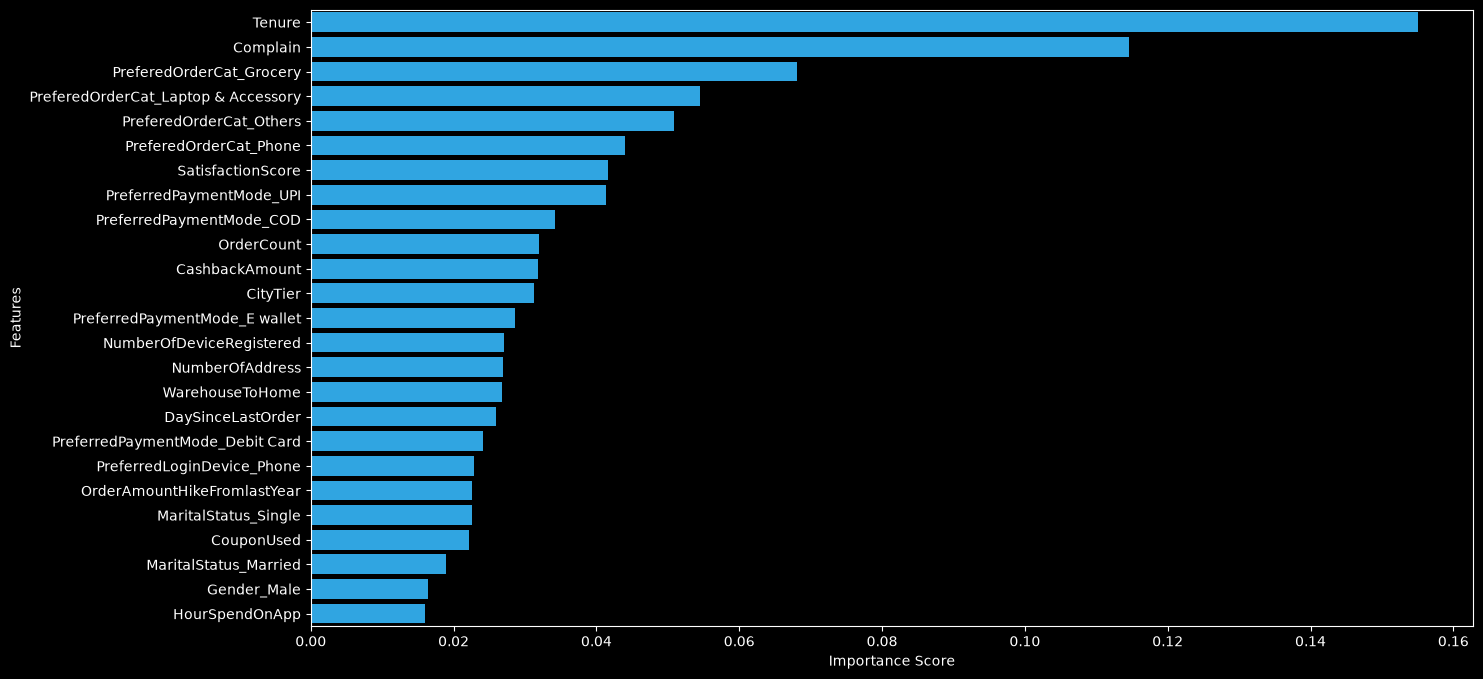

In [15]:
importances = pd.Series(op_model.feature_importances_, index=x_test.columns).sort_values(ascending=False)
plt.figure(figsize = (15, 8))
sns.barplot(x = importances, y = importances.index, color = "#12aeff")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()

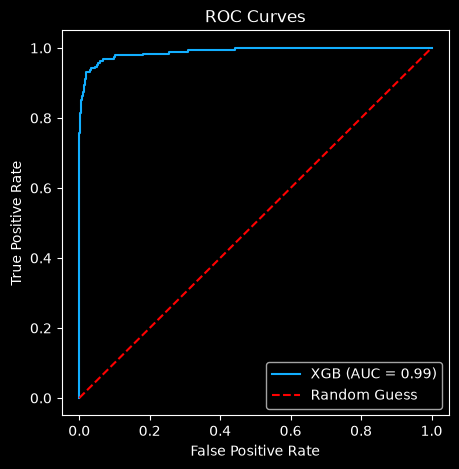

In [16]:
plt.figure(figsize=(5, 5))
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr, label = f'XGB (AUC = {roc_auc:.2f})', color = "#12aeff")
plt.plot([0, 1], [0, 1], 'r--', label = 'Random Guess')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')

plt.legend()
plt.show()

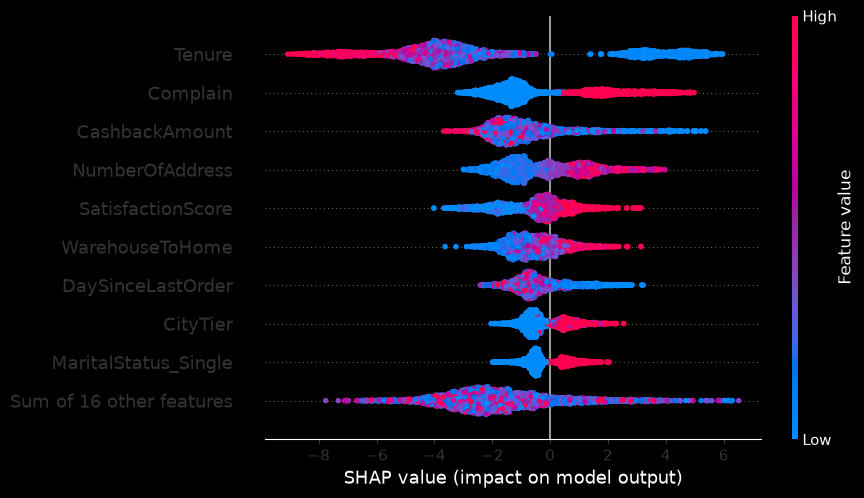

In [17]:
explainer = shap.Explainer(op_model)
shap_values = explainer(x_train)
shap.plots.beeswarm(shap_values)

# 5. Save model

In [18]:
import os, json
path = os.getcwd().replace("notebooks", "models")

In [19]:
# Model
op_model.save_model(path + "\\op_model.json")

# Features
with open('../models/top_10_features.json', 'w') as f:
    json.dump(importances.index[:10].to_list(), f)

# Hyperparams
with open('../models/best_params.json', 'w') as f:
    json.dump(study.best_params, f)

# Metrics
metrics = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1": f1_score(y_test, y_pred),
    "AUC": roc_auc
}
with open('../models/best_metrics.json', 'w') as f:
    json.dump(metrics, f)